In [1]:
pip install numpy matplotlib scikit-learn xgboost torch transformers

Note: you may need to restart the kernel to use updated packages.


# ML Deep Dive: From First Principles to Implementation

This notebook explains **how** every model and concept in Assignment 2 actually works —
not just what it does, but the math, the intuition, and the code from scratch.

We build everything from the ground up using toy examples so you can see every step.
Then we compare with library implementations to confirm our understanding.

**Contents:**
1. Decision Trees → Random Forest → Gradient Boosting → **XGBoost**
2. Perceptron → **Multi-Layer Perceptron (MLP)** → Backpropagation
3. RNN → **LSTM**
4. Entropy → **Mutual Information** → Feature Importance
5. Game Theory → **SHAP (Shapley Values)**
6. Tokenization → Embeddings → Attention → Transformers → **RoBERTa**

---
# Part 1: From Decision Trees to XGBoost

## 1.1 Decision Trees

### Intuition: The "20 Questions" Game

A decision tree works exactly like the game "20 Questions." You ask a series of yes/no questions
to narrow down the answer:

```
                   Is temperature > 75°F?
                   /                    \
                 YES                     NO
                /                          \
       Is humidity > 80%?              Is it windy?
       /              \                /           \
     YES              NO             YES            NO
      |                |              |              |
  Don't play        Play          Don't play       Play
```

Each **internal node** asks a question about one feature. Each **leaf** gives a prediction.
The tree learns which questions to ask and in what order by looking at training data.

### The Key Question: How Does It Choose the Best Split?

Given a feature (e.g., temperature) and a threshold (e.g., 75°F), the tree needs to measure
how "good" this split is. A good split **separates the classes** as cleanly as possible.

### Gini Impurity

**Gini impurity** measures how "mixed" a group is:

$$Gini = 1 - \sum_{i=1}^{C} p_i^2$$

where $p_i$ is the proportion of class $i$ in the group.

**Examples with concrete numbers:**
- A group of [5 cats, 0 dogs]: Gini = 1 - (5/5)² - (0/5)² = 1 - 1 - 0 = **0.0** (pure! perfect split)
- A group of [3 cats, 3 dogs]: Gini = 1 - (3/6)² - (3/6)² = 1 - 0.25 - 0.25 = **0.5** (maximum impurity)
- A group of [4 cats, 1 dog]: Gini = 1 - (4/5)² - (1/5)² = 1 - 0.64 - 0.04 = **0.32** (mostly pure)

The tree tries every possible split and picks the one that results in the **lowest weighted
average Gini** across the two child groups.

### Information Gain (Alternative to Gini)

Instead of Gini, we can use **entropy** (we'll cover this in detail in Part 4):

$$Entropy = -\sum_{i=1}^{C} p_i \log_2(p_i)$$

**Information Gain** = parent entropy - weighted average of children's entropy.
Higher gain = better split. In practice, Gini and entropy give very similar results.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Let's build a decision tree from scratch ----

# Toy dataset: predict if someone will buy a product
# Features: [age, income($k)]  |  Target: 1=buy, 0=no buy
X_toy = np.array([
    [25, 40],   # young, low income
    [35, 60],   # mid-age, mid income
    [45, 80],   # mid-age, high income
    [20, 30],   # young, low income
    [55, 90],   # older, high income
    [30, 50],   # mid-age, mid income
    [50, 70],   # older, mid income
    [22, 35],   # young, low income
    [40, 85],   # mid-age, high income
    [60, 95],   # older, high income
])
y_toy = np.array([0, 0, 1, 0, 1, 0, 1, 0, 1, 1])  # 5 buyers, 5 non-buyers
feature_names = ['Age', 'Income ($k)']

def gini_impurity(y):
    """Compute Gini impurity of a group."""
    if len(y) == 0:
        return 0
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return 1 - np.sum(probs ** 2)

# Let's compute Gini for the whole dataset
print(f"Full dataset: {len(y_toy)} samples, {sum(y_toy)} buyers, {sum(1-y_toy)} non-buyers")
print(f"Gini impurity of full dataset: {gini_impurity(y_toy):.4f}")
print(f"  (0.5 = maximum impurity for binary classification)")
print()

# Now let's try ALL possible splits and find the best one
def find_best_split(X, y):
    """Try every feature and every threshold. Return the best split."""
    best_gini = float('inf')
    best_feature = None
    best_threshold = None

    n_samples = len(y)

    for feature_idx in range(X.shape[1]):
        # Get unique values and try midpoints as thresholds
        values = np.sort(np.unique(X[:, feature_idx]))
        thresholds = (values[:-1] + values[1:]) / 2  # midpoints between consecutive values

        for threshold in thresholds:
            # Split
            left_mask = X[:, feature_idx] <= threshold
            right_mask = ~left_mask

            y_left = y[left_mask]
            y_right = y[right_mask]

            # Weighted average Gini
            w_left = len(y_left) / n_samples
            w_right = len(y_right) / n_samples
            weighted_gini = w_left * gini_impurity(y_left) + w_right * gini_impurity(y_right)

            if weighted_gini < best_gini:
                best_gini = weighted_gini
                best_feature = feature_idx
                best_threshold = threshold

    return best_feature, best_threshold, best_gini

# Find the best first split
feat, thresh, gini = find_best_split(X_toy, y_toy)
print(f"Best split: {feature_names[feat]} <= {thresh}")
print(f"Weighted Gini after split: {gini:.4f} (down from 0.5000)")

# Show what happens with this split
left_mask = X_toy[:, feat] <= thresh
print(f"\nLeft group ({feature_names[feat]} <= {thresh}):")
print(f"  Samples: {X_toy[left_mask].tolist()}")
print(f"  Labels:  {y_toy[left_mask].tolist()}")
print(f"  Gini:    {gini_impurity(y_toy[left_mask]):.4f}")

print(f"\nRight group ({feature_names[feat]} > {thresh}):")
print(f"  Samples: {X_toy[~left_mask].tolist()}")
print(f"  Labels:  {y_toy[~left_mask].tolist()}")
print(f"  Gini:    {gini_impurity(y_toy[~left_mask]):.4f}")

Full dataset: 10 samples, 5 buyers, 5 non-buyers
Gini impurity of full dataset: 0.5000
  (0.5 = maximum impurity for binary classification)

Best split: Age <= 37.5
Weighted Gini after split: 0.0000 (down from 0.5000)

Left group (Age <= 37.5):
  Samples: [[25, 40], [35, 60], [20, 30], [30, 50], [22, 35]]
  Labels:  [0, 0, 0, 0, 0]
  Gini:    0.0000

Right group (Age > 37.5):
  Samples: [[45, 80], [55, 90], [50, 70], [40, 85], [60, 95]]
  Labels:  [1, 1, 1, 1, 1]
  Gini:    0.0000


In [3]:
# ---- Build a full decision tree from scratch ----

class DecisionTreeNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, prediction=None):
        self.feature = feature          # which feature to split on
        self.threshold = threshold      # split threshold
        self.left = left                # left child (values <= threshold)
        self.right = right              # right child (values > threshold)
        self.prediction = prediction    # leaf prediction (None if internal node)

def build_tree(X, y, depth=0, max_depth=3):
    """Recursively build a decision tree."""
    # Base cases: stop splitting
    if len(np.unique(y)) == 1:  # all same class → pure leaf
        return DecisionTreeNode(prediction=y[0])
    if depth >= max_depth:      # max depth reached → majority vote
        return DecisionTreeNode(prediction=int(np.mean(y) >= 0.5))
    if len(y) < 2:              # too few samples
        return DecisionTreeNode(prediction=int(np.mean(y) >= 0.5))

    # Find best split
    feat, thresh, gini = find_best_split(X, y)
    if gini >= gini_impurity(y):  # split doesn't improve → stop
        return DecisionTreeNode(prediction=int(np.mean(y) >= 0.5))

    # Recurse
    left_mask = X[:, feat] <= thresh
    left_child = build_tree(X[left_mask], y[left_mask], depth + 1, max_depth)
    right_child = build_tree(X[~left_mask], y[~left_mask], depth + 1, max_depth)

    return DecisionTreeNode(feature=feat, threshold=thresh, left=left_child, right=right_child)

def predict_one(node, x):
    """Predict for a single sample by traversing the tree."""
    if node.prediction is not None:  # leaf
        return node.prediction
    if x[node.feature] <= node.threshold:
        return predict_one(node.left, x)
    else:
        return predict_one(node.right, x)

def print_tree(node, depth=0, prefix="Root"):
    """Print the tree structure."""
    indent = "  " * depth
    if node.prediction is not None:
        label = "BUY" if node.prediction == 1 else "NO BUY"
        print(f"{indent}{prefix} → Predict: {label}")
    else:
        print(f"{indent}{prefix}: {feature_names[node.feature]} <= {node.threshold}?")
        print_tree(node.left, depth + 1, "YES")
        print_tree(node.right, depth + 1, "NO ")

# Build and display
tree = build_tree(X_toy, y_toy, max_depth=3)
print("Decision Tree Structure:")
print("=" * 50)
print_tree(tree)

# Test predictions
preds = np.array([predict_one(tree, x) for x in X_toy])
accuracy = np.mean(preds == y_toy)
print(f"\nTraining accuracy: {accuracy:.1%}")
print(f"Predictions: {preds.tolist()}")
print(f"Actual:      {y_toy.tolist()}")

Decision Tree Structure:
Root: Age <= 37.5?
  YES → Predict: NO BUY
  NO  → Predict: BUY

Training accuracy: 100.0%
Predictions: [0, 0, 1, 0, 1, 0, 1, 0, 1, 1]
Actual:      [0, 0, 1, 0, 1, 0, 1, 0, 1, 1]


### The Overfitting Problem

A deep decision tree can achieve **100% training accuracy** by creating a leaf for every single
training sample. But it memorizes the training data instead of learning general patterns.

On new data it's never seen, it performs terribly. This is **overfitting**.

```
Shallow tree (depth=2):          Deep tree (depth=10):
  - Simple rules                   - Complex rules
  - Misses some training points    - Gets every training point right
  - Generalizes well               - Memorizes noise
  - Good test accuracy             - Poor test accuracy
```

**Solutions to overfitting:**
1. Limit tree depth (max_depth)
2. Require minimum samples per leaf
3. **Use many trees instead of one** → this leads us to ensemble methods

## 1.2 Ensemble Methods: Bagging vs Boosting

### Intuition: Wisdom of Crowds

If you ask one person to guess the number of jelly beans in a jar, they'll probably be off.
But if you ask 100 people and **average** their guesses, the average is usually very close.

This is the core idea behind ensemble methods: **combine many weak models into one strong model.**

### Two Approaches

| | **Bagging** (Random Forest) | **Boosting** (XGBoost) |
|---|---|---|
| **How** | Train many trees **independently** on random subsets of data | Train trees **sequentially**, each fixing previous mistakes |
| **Combination** | Average (or majority vote) all trees | Weighted sum of all trees |
| **Focus** | Reduce **variance** (overfitting) | Reduce **bias** (underfitting) |
| **Analogy** | Ask 100 random people, take the average | Ask an expert, then ask another expert to correct the first one's mistakes, then another... |

### Bagging (Bootstrap Aggregating)

1. Take the training data (N samples)
2. Create B random subsets by sampling **with replacement** (some samples appear twice, some not at all)
3. Train one tree on each subset
4. For prediction: each tree votes, take the majority

**Random Forest** adds one more trick: at each split, only consider a random subset of features.
This forces the trees to be different from each other (decorrelation).

### Boosting

1. Train tree #1 on the full data
2. Look at which samples tree #1 got **wrong**
3. Train tree #2, giving **more weight** to the misclassified samples
4. Repeat: each new tree focuses on what previous trees got wrong
5. Final prediction: weighted sum of all trees

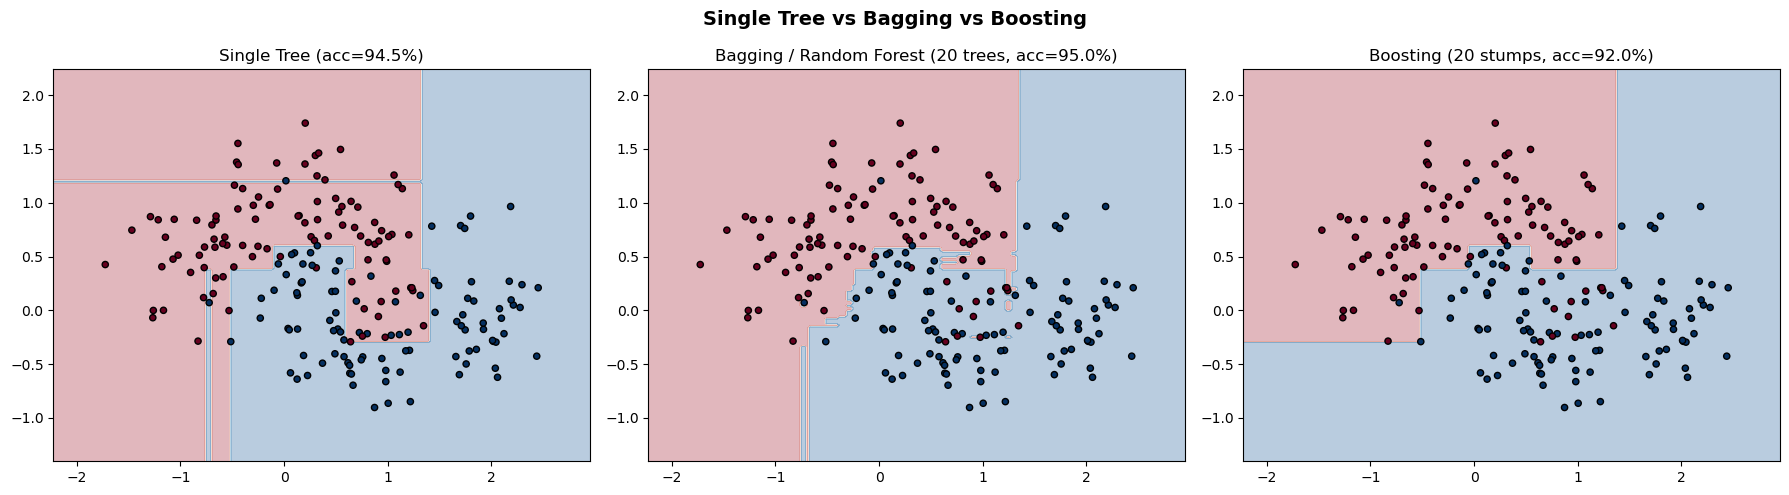

Notice:
- Single tree: jagged boundaries, overfits to individual points
- Bagging: smoother boundaries, averages out individual trees' quirks
- Boosting: smooth boundaries too, but focused on getting hard cases right


In [4]:
# ---- Bagging vs Boosting: Visual Demo ----

from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_moons

# Create a dataset that's hard for a single tree
np.random.seed(42)
X_moons, y_moons = make_moons(n_samples=200, noise=0.3, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---- Single Decision Tree ----
single_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
single_tree.fit(X_moons, y_moons)

# Create grid for visualization
xx, yy = np.meshgrid(np.linspace(X_moons[:, 0].min()-0.5, X_moons[:, 0].max()+0.5, 200),
                      np.linspace(X_moons[:, 1].min()-0.5, X_moons[:, 1].max()+0.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

Z = single_tree.predict(grid).reshape(xx.shape)
axes[0].contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='RdBu', edgecolors='k', s=20)
axes[0].set_title(f'Single Tree (acc={single_tree.score(X_moons, y_moons):.1%})')

# ---- Bagging (Manual Random Forest) ----
n_trees = 20
bagging_preds = np.zeros((len(grid), n_trees))
for i in range(n_trees):
    # Bootstrap sample (sample with replacement)
    idx = np.random.choice(len(X_moons), size=len(X_moons), replace=True)
    tree = DecisionTreeClassifier(max_depth=5, max_features='sqrt')
    tree.fit(X_moons[idx], y_moons[idx])
    bagging_preds[:, i] = tree.predict(grid)

# Majority vote
Z_bag = (bagging_preds.mean(axis=1) >= 0.5).astype(int).reshape(xx.shape)
bag_acc = np.mean((bagging_preds.mean(axis=1) >= 0.5).astype(int)[:len(X_moons)] == y_moons[:len(grid)])
axes[1].contourf(xx, yy, Z_bag, alpha=0.3, cmap='RdBu')
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='RdBu', edgecolors='k', s=20)
# Compute actual bagging accuracy on training data
bag_train_pred = np.zeros((len(X_moons), n_trees))
for i in range(n_trees):
    idx = np.random.choice(len(X_moons), size=len(X_moons), replace=True)
    tree = DecisionTreeClassifier(max_depth=5, max_features='sqrt')
    tree.fit(X_moons[idx], y_moons[idx])
    bag_train_pred[:, i] = tree.predict(X_moons)
bag_acc = np.mean((bag_train_pred.mean(axis=1) >= 0.5).astype(int) == y_moons)
axes[1].set_title(f'Bagging / Random Forest ({n_trees} trees, acc={bag_acc:.1%})')

# ---- Boosting (Manual AdaBoost-style) ----
sample_weights = np.ones(len(X_moons)) / len(X_moons)  # uniform initially
boost_trees = []
boost_alphas = []

for i in range(n_trees):
    tree = DecisionTreeClassifier(max_depth=1)  # weak learner (stump)
    tree.fit(X_moons, y_moons, sample_weight=sample_weights)
    pred = tree.predict(X_moons)

    # Compute weighted error
    err = np.sum(sample_weights * (pred != y_moons)) / np.sum(sample_weights)
    err = max(err, 1e-10)  # avoid log(0)

    # Compute tree weight (more accurate trees get higher weight)
    alpha = 0.5 * np.log((1 - err) / err)

    # Update sample weights: increase weight of misclassified samples
    sample_weights *= np.exp(-alpha * (2 * y_moons - 1) * (2 * pred - 1))
    sample_weights /= sample_weights.sum()

    boost_trees.append(tree)
    boost_alphas.append(alpha)

# Boosting prediction: weighted vote
boost_pred_grid = np.zeros(len(grid))
for tree, alpha in zip(boost_trees, boost_alphas):
    boost_pred_grid += alpha * (2 * tree.predict(grid) - 1)
Z_boost = (boost_pred_grid >= 0).astype(int).reshape(xx.shape)

boost_pred_train = np.zeros(len(X_moons))
for tree, alpha in zip(boost_trees, boost_alphas):
    boost_pred_train += alpha * (2 * tree.predict(X_moons) - 1)
boost_acc = np.mean((boost_pred_train >= 0).astype(int) == y_moons)

axes[2].contourf(xx, yy, Z_boost, alpha=0.3, cmap='RdBu')
axes[2].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='RdBu', edgecolors='k', s=20)
axes[2].set_title(f'Boosting ({n_trees} stumps, acc={boost_acc:.1%})')

plt.suptitle('Single Tree vs Bagging vs Boosting', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Notice:")
print("- Single tree: jagged boundaries, overfits to individual points")
print("- Bagging: smoother boundaries, averages out individual trees' quirks")
print("- Boosting: smooth boundaries too, but focused on getting hard cases right")

## 1.3 Gradient Boosting: The Math Behind XGBoost

### The Core Idea

Gradient Boosting is a specific type of boosting. Instead of reweighting samples (like AdaBoost above),
it works by **fitting each new tree to the residual errors** of the previous trees.

Think of it as iterative correction:
- **Round 1**: Predict y. You'll be wrong. Compute errors (residuals).
- **Round 2**: Predict the **errors from Round 1**. Now add this correction to Round 1's prediction.
- **Round 3**: Predict the **remaining errors**. Add correction.
- ...each round, the residuals get smaller.

### Step by Step (Regression Example)

Say we have 5 data points and want to predict house prices:

| House | True Price | Round 1 Pred | Residual | Round 2 Pred (of residual) | Final Pred |
|-------|-----------|-------------|----------|---------------------------|-----------|
| A | $300k | $250k | +$50k | +$40k | $290k |
| B | $200k | $250k | -$50k | -$45k | $205k |
| C | $350k | $250k | +$100k | +$80k | $330k |

Round 1 starts with a simple prediction (e.g., the mean: $250k for all houses).
Round 2 trains a tree to predict the residuals (+50, -50, +100, ...).
We add the correction: $250k + $40k = $290k. Closer to the true $300k!

### The Math

Given a loss function $L(y, \hat{y})$ (e.g., MSE = $(y - \hat{y})^2$):

1. Start with initial prediction: $F_0(x) = \arg\min_c \sum L(y_i, c)$ (usually the mean)
2. For each round $m = 1, 2, ..., M$:
   - Compute **pseudo-residuals**: $r_i = -\frac{\partial L(y_i, F_{m-1}(x_i))}{\partial F_{m-1}(x_i)}$
   - For MSE: residuals are simply $r_i = y_i - F_{m-1}(x_i)$ (the prediction errors)
   - Fit a decision tree $h_m(x)$ to these residuals
   - Update: $F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$

$\eta$ is the **learning rate** (e.g., 0.1). It shrinks each tree's contribution to prevent
overfitting. Think of it as "don't overcorrect" — take small steps toward the answer.

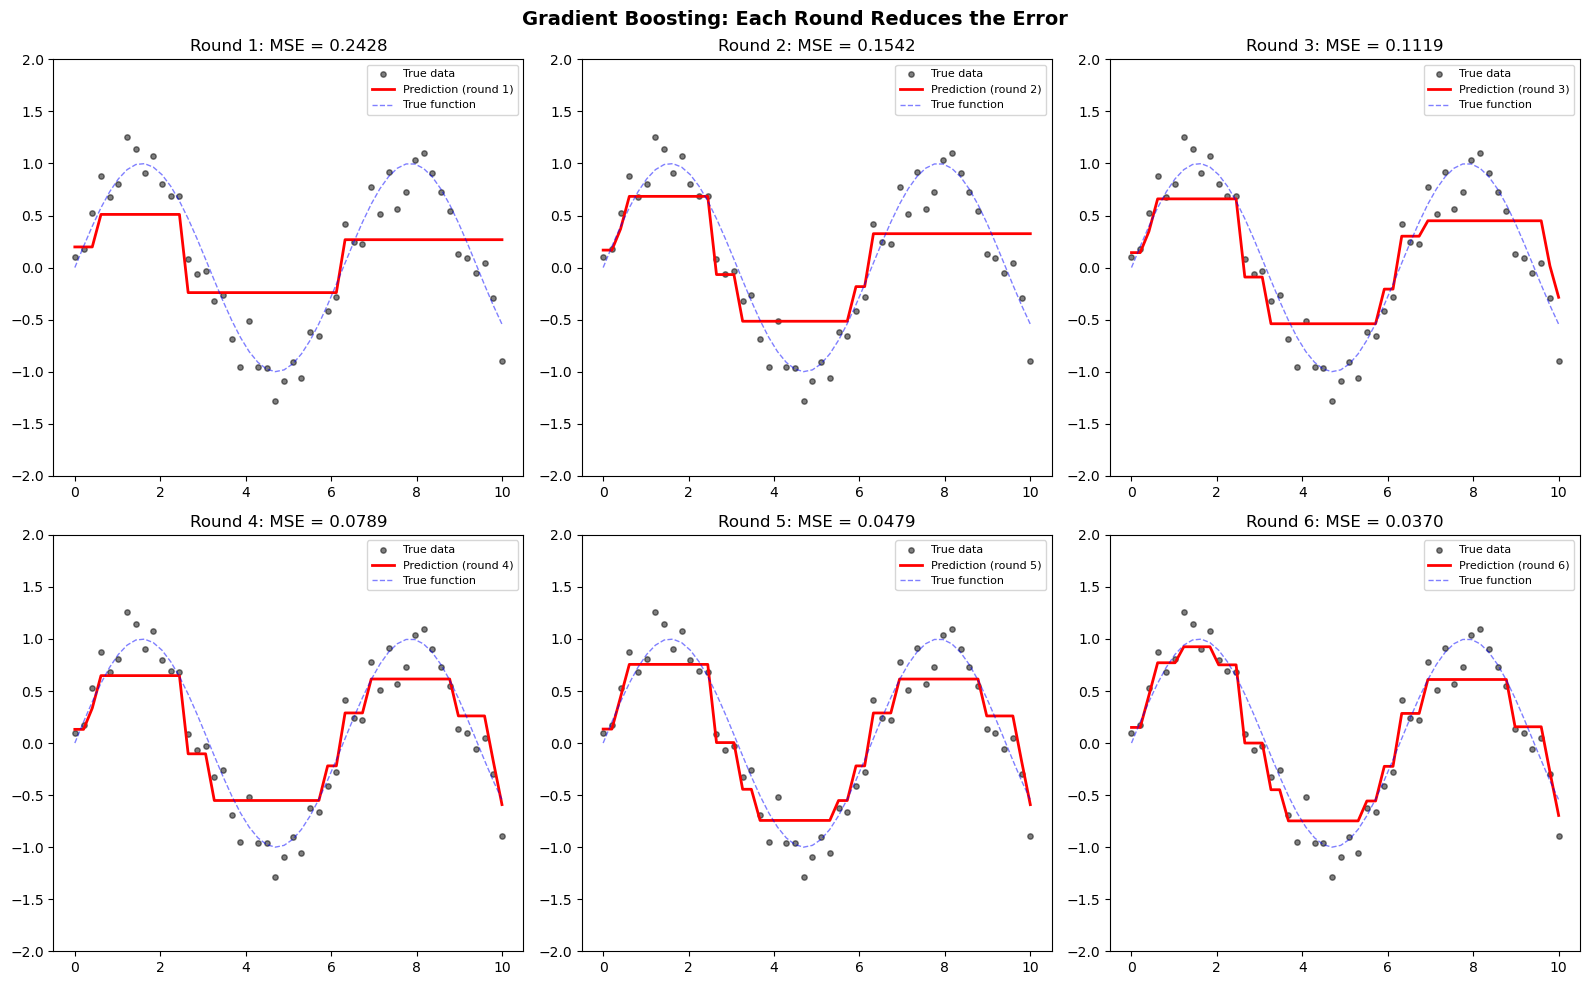

Starting MSE (just the mean): 0.5004
Final MSE after 6 rounds:  0.0370

Notice how the red line gets closer to the true sine wave with each round.
Each tree learns to correct what the previous trees got wrong.


In [5]:
# ---- Gradient Boosting from Scratch (Regression) ----

np.random.seed(42)

# Toy regression data: predict y from x
x_gb = np.linspace(0, 10, 50)
y_gb = np.sin(x_gb) + np.random.normal(0, 0.2, 50)  # sine wave + noise

# Gradient Boosting parameters
n_rounds = 6
learning_rate = 0.5
max_depth = 2

# Step 1: Initial prediction = mean of y
F = np.full_like(y_gb, y_gb.mean())

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for m in range(n_rounds):
    # Step 2: Compute residuals (for MSE, residual = y - prediction)
    residuals = y_gb - F

    # Step 3: Fit a tree to the residuals
    from sklearn.tree import DecisionTreeRegressor
    tree = DecisionTreeRegressor(max_depth=max_depth)
    tree.fit(x_gb.reshape(-1, 1), residuals)

    # Step 4: Update prediction
    correction = learning_rate * tree.predict(x_gb.reshape(-1, 1))
    F = F + correction

    # Plot
    ax = axes[m]
    ax.scatter(x_gb, y_gb, color='black', s=15, alpha=0.5, label='True data')
    ax.plot(x_gb, F, color='red', linewidth=2, label=f'Prediction (round {m+1})')
    ax.plot(x_gb, np.sin(x_gb), color='blue', linewidth=1, linestyle='--', alpha=0.5, label='True function')
    mse = np.mean((y_gb - F) ** 2)
    ax.set_title(f'Round {m+1}: MSE = {mse:.4f}')
    ax.legend(fontsize=8)
    ax.set_ylim(-2, 2)

plt.suptitle('Gradient Boosting: Each Round Reduces the Error', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Starting MSE (just the mean): {np.mean((y_gb - y_gb.mean())**2):.4f}")
print(f"Final MSE after {n_rounds} rounds:  {np.mean((y_gb - F)**2):.4f}")
print(f"\nNotice how the red line gets closer to the true sine wave with each round.")
print(f"Each tree learns to correct what the previous trees got wrong.")

## 1.4 XGBoost: What Makes It Special

XGBoost (eXtreme Gradient Boosting) is gradient boosting with several enhancements that make it
faster, more accurate, and less prone to overfitting.

### Enhancement 1: Second-Order Gradients (Newton's Method)

Standard gradient boosting uses the **first derivative** (gradient) of the loss function.
XGBoost also uses the **second derivative** (Hessian), which gives it curvature information.

Analogy: Imagine rolling a ball downhill to find the lowest point.
- **Gradient only**: You know the slope (which direction is downhill), but not how steep it is. You might overshoot.
- **Gradient + Hessian**: You know both the slope AND the curvature. If the curve is gentle, take a big step. If it's steep, take a small step. Much more efficient.

For binary classification with log-loss:
- Gradient: $g_i = \hat{y}_i - y_i$ (predicted probability minus true label)
- Hessian: $h_i = \hat{y}_i (1 - \hat{y}_i)$ (measures prediction confidence)

### Enhancement 2: Regularization

XGBoost's objective function has an explicit **penalty term** to prevent overfitting:

$$Obj = \sum_{i=1}^{n} L(y_i, \hat{y}_i) + \sum_{k=1}^{K} \Omega(f_k)$$

where $\Omega(f) = \gamma T + \frac{1}{2}\lambda \sum_{j=1}^{T} w_j^2$

| Symbol | Meaning | Effect |
|--------|---------|--------|
| $T$ | Number of leaves in the tree | More leaves = more complex tree |
| $\gamma$ | Penalty per leaf | Higher γ → fewer leaves → simpler trees |
| $w_j$ | Leaf weight (prediction value) | The output value at each leaf |
| $\lambda$ | L2 regularization on leaf weights | Higher λ → smaller leaf weights → more conservative predictions |

This is like telling the model: "I want you to be accurate, **but also simple**. Every extra leaf
costs you γ points, so you better make sure that extra leaf really helps."

### Enhancement 3: Column Subsampling

Like Random Forest, XGBoost can randomly select a subset of features at each split. This:
- Decorrelates the trees (they don't all rely on the same dominant feature)
- Speeds up training (fewer features to evaluate)
- Reduces overfitting

### Enhancement 4: Histogram-Based Splitting

Instead of trying every possible threshold (slow), XGBoost bins continuous features into
~256 buckets and only tries bucket boundaries. This is approximate but much faster.

### Why XGBoost Dominates Tabular Data

1. Trees naturally handle **mixed feature types** (some features are ratios, some counts, some correlations)
2. Trees capture **feature interactions** automatically (if age > 40 AND income > 80k → buy)
3. Regularization prevents overfitting without extensive hyperparameter tuning
4. Fast training enables large-scale experiments

In [6]:
# ---- Compare our from-scratch Gradient Boosting vs XGBoost Library ----

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import xgboost as xgb

# Create a binary classification dataset
X_cls, y_cls = make_classification(n_samples=500, n_features=10, n_informative=5,
                                    n_redundant=3, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_cls, y_cls, test_size=0.3, random_state=42)

# ---- Our from-scratch gradient boosting (for classification) ----
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

# Initialize with log-odds of positive class
pos_ratio = y_tr.mean()
F_train = np.full(len(y_tr), np.log(pos_ratio / (1 - pos_ratio)))
F_test = np.full(len(y_te), np.log(pos_ratio / (1 - pos_ratio)))

n_rounds = 50
lr = 0.3
trees = []

for m in range(n_rounds):
    # Predicted probabilities
    p_train = sigmoid(F_train)

    # Gradients for log-loss (first derivative)
    gradients = p_train - y_tr

    # Fit tree to negative gradients (= residuals for classification)
    tree = DecisionTreeRegressor(max_depth=3)
    tree.fit(X_tr, -gradients)
    trees.append(tree)

    # Update predictions
    F_train += lr * tree.predict(X_tr)
    F_test += lr * tree.predict(X_te)

# Our predictions
our_pred = (sigmoid(F_test) >= 0.5).astype(int)
our_acc = np.mean(our_pred == y_te)

# ---- XGBoost library ----
xgb_model = xgb.XGBClassifier(n_estimators=50, max_depth=3, learning_rate=0.3,
                                random_state=42, eval_metric='logloss')
xgb_model.fit(X_tr, y_tr)
xgb_pred = xgb_model.predict(X_te)
xgb_acc = np.mean(xgb_pred == y_te)

print("=" * 50)
print("COMPARISON: Our GB vs XGBoost Library")
print("=" * 50)
print(f"Our from-scratch GB:  {our_acc:.4f} accuracy")
print(f"XGBoost library:      {xgb_acc:.4f} accuracy")
print(f"\nThey're close! XGBoost is slightly better because of:")
print(f"  - Second-order gradients (Hessian)")
print(f"  - Built-in regularization (gamma, lambda)")
print(f"  - Better leaf weight computation")
print(f"\nBut the core idea is identical: fit trees to residual errors.")

COMPARISON: Our GB vs XGBoost Library
Our from-scratch GB:  0.9267 accuracy
XGBoost library:      0.9133 accuracy

They're close! XGBoost is slightly better because of:
  - Second-order gradients (Hessian)
  - Built-in regularization (gamma, lambda)
  - Better leaf weight computation

But the core idea is identical: fit trees to residual errors.


---
# Part 2: From Perceptrons to Multi-Layer Perceptrons

## 2.1 The Single Perceptron

### Intuition: A Neuron as a Weighted Vote

A perceptron mimics a simplified biological neuron. It takes multiple inputs, multiplies each by
a **weight** (importance), adds them up, and decides "yes" or "no" based on a threshold.

```
  Input 1 (x₁) ──── w₁ ────┐
                              │
  Input 2 (x₂) ──── w₂ ────┼──→ [ Σ + b ] ──→ [ activation ] ──→ Output
                              │
  Input 3 (x₃) ──── w₃ ────┘
```

**Mathematically:**
$$z = w_1 x_1 + w_2 x_2 + w_3 x_3 + b$$
$$output = activation(z)$$

- **Weights** ($w_i$): How important is each input? Learned from data.
- **Bias** ($b$): A threshold offset. Like the intercept in linear regression.
- **Activation function**: Converts the sum to a useful output (e.g., 0 or 1).

### Learning: How Does a Perceptron Find the Right Weights?

It uses a simple rule:
1. Make a prediction
2. Check if it's wrong
3. If wrong, nudge the weights in the direction that would have been correct
4. Repeat

This is the simplest form of **gradient descent** — adjust weights proportionally to the error.

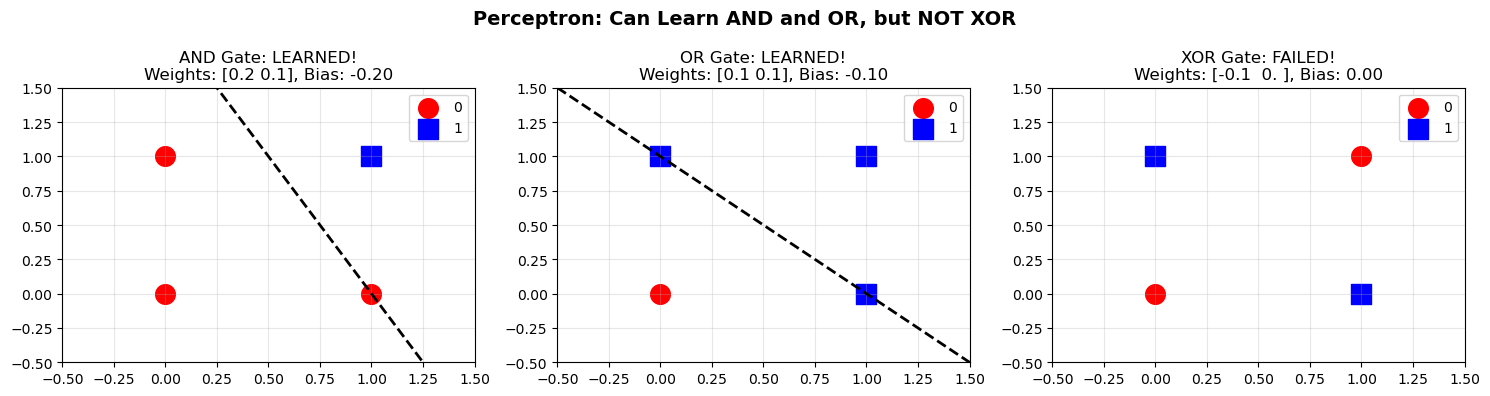

The perceptron FAILS on XOR because XOR is not linearly separable.
You can't draw a single straight line to separate the 0s from the 1s.

This was a famous limitation discovered in 1969 (Minsky & Papert).
The solution? Add more layers → Multi-Layer Perceptron (MLP).


In [7]:
# ---- Perceptron from Scratch ----

class Perceptron:
    def __init__(self, n_inputs, learning_rate=0.1):
        self.weights = np.zeros(n_inputs)
        self.bias = 0
        self.lr = learning_rate

    def predict(self, x):
        z = np.dot(self.weights, x) + self.bias
        return 1 if z >= 0 else 0  # step function activation

    def train(self, X, y, epochs=20):
        history = []
        for epoch in range(epochs):
            errors = 0
            for xi, yi in zip(X, y):
                pred = self.predict(xi)
                error = yi - pred  # +1 if should be 1 but predicted 0, -1 if opposite

                # Update weights: nudge toward correct answer
                self.weights += self.lr * error * xi
                self.bias += self.lr * error
                errors += abs(error)
            history.append(errors)
            if errors == 0:
                break
        return history

# ---- Test on logic gates ----
# AND gate: output 1 only if BOTH inputs are 1
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])

# OR gate: output 1 if EITHER input is 1
X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_or = np.array([0, 1, 1, 1])

# XOR gate: output 1 if inputs are DIFFERENT
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, X_gate, y_gate) in zip(axes, [('AND', X_and, y_and), ('OR', X_or, y_or), ('XOR', X_xor, y_xor)]):
    p = Perceptron(2, learning_rate=0.1)
    hist = p.train(X_gate, y_gate, epochs=20)

    # Test
    preds = [p.predict(x) for x in X_gate]
    correct = all(p == t for p, t in zip(preds, y_gate))

    ax.scatter(X_gate[y_gate == 0, 0], X_gate[y_gate == 0, 1], marker='o', s=200, c='red', label='0')
    ax.scatter(X_gate[y_gate == 1, 0], X_gate[y_gate == 1, 1], marker='s', s=200, c='blue', label='1')

    # Draw decision boundary if weights are non-zero
    if np.any(p.weights != 0):
        x_line = np.linspace(-0.5, 1.5, 100)
        if p.weights[1] != 0:
            y_line = -(p.weights[0] * x_line + p.bias) / p.weights[1]
            ax.plot(x_line, y_line, 'k--', linewidth=2)

    status = "LEARNED!" if correct else "FAILED!"
    ax.set_title(f'{name} Gate: {status}\nWeights: {p.weights.round(2)}, Bias: {p.bias:.2f}')
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Perceptron: Can Learn AND and OR, but NOT XOR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("The perceptron FAILS on XOR because XOR is not linearly separable.")
print("You can't draw a single straight line to separate the 0s from the 1s.")
print("\nThis was a famous limitation discovered in 1969 (Minsky & Papert).")
print("The solution? Add more layers → Multi-Layer Perceptron (MLP).")

## 2.2 Multi-Layer Perceptron (MLP)

### Solving XOR: Why We Need Hidden Layers

A single perceptron draws one straight line. XOR needs a **curved** boundary.
By stacking neurons into layers, each layer can transform the input space:

```
Input Layer      Hidden Layer       Output Layer
  x₁ ──────→  [neuron 1] ──────→
               [neuron 2] ──────→  [output neuron] → ŷ
  x₂ ──────→  [neuron 3] ──────→
```

The hidden layer **transforms** the inputs into a new representation where the problem
becomes linearly separable. Then the output layer draws a straight line in that new space.

### Activation Functions: Why Nonlinearity Matters

Without activation functions, stacking layers is useless. Two linear transformations in a row
($y = W_2(W_1 x)$) is just another linear transformation ($y = W_{combined} x$). You'd get
no benefit from extra layers.

**Activation functions** add nonlinearity, allowing the network to learn curved boundaries:

| Function | Formula | Range | Used for |
|----------|---------|-------|----------|
| **Sigmoid** | $\sigma(z) = \frac{1}{1+e^{-z}}$ | (0, 1) | Output layer (probabilities) |
| **ReLU** | $\max(0, z)$ | [0, ∞) | Hidden layers (most popular) |
| **Tanh** | $\frac{e^z - e^{-z}}{e^z + e^{-z}}$ | (-1, 1) | Hidden layers (alternative) |

**ReLU** is popular because it's simple and doesn't suffer from the "vanishing gradient" problem
(which we'll discuss in Part 3 with LSTMs).

XOR Problem - MLP from Scratch:
     Input    True   Predicted   Rounded
     [0 0]       0      0.0270         0
     [0 1]       1      0.9728         1
     [1 0]       1      0.9774         1
     [1 1]       0      0.0268         0


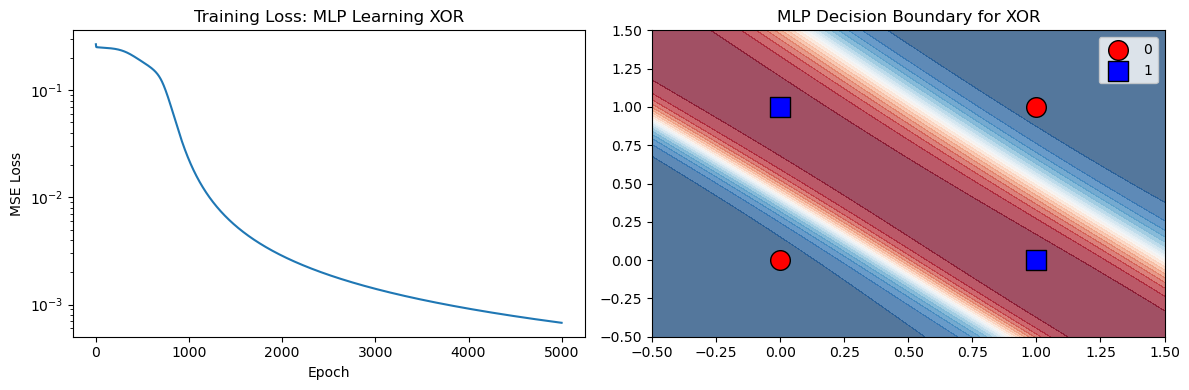


The MLP learned a CURVED boundary that separates XOR correctly!
A single perceptron could never do this — it can only draw straight lines.


In [8]:
# ---- MLP from Scratch: Solving XOR ----

class MLPFromScratch:
    def __init__(self, layer_sizes, learning_rate=0.5):
        """
        layer_sizes: e.g., [2, 4, 1] means 2 inputs, 4 hidden neurons, 1 output
        """
        self.lr = learning_rate
        self.weights = []
        self.biases = []

        # Initialize weights randomly (Xavier initialization)
        for i in range(len(layer_sizes) - 1):
            w = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * np.sqrt(2 / layer_sizes[i])
            b = np.zeros(layer_sizes[i+1])
            self.weights.append(w)
            self.biases.append(b)

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def sigmoid_derivative(self, a):
        """Derivative of sigmoid: σ'(z) = σ(z) * (1 - σ(z))"""
        return a * (1 - a)

    def forward(self, X):
        """Forward pass: compute output layer by layer."""
        self.activations = [X]  # store for backprop

        current = X
        for w, b in zip(self.weights, self.biases):
            z = current @ w + b          # matrix multiply + bias
            current = self.sigmoid(z)     # apply activation
            self.activations.append(current)

        return current

    def backward(self, y):
        """Backward pass (backpropagation): compute gradients and update weights."""
        m = len(y)
        y = y.reshape(-1, 1) if y.ndim == 1 else y

        # Start from output layer
        delta = (self.activations[-1] - y) * self.sigmoid_derivative(self.activations[-1])

        # Go backwards through layers
        for i in range(len(self.weights) - 1, -1, -1):
            # Gradient for weights at this layer
            dW = self.activations[i].T @ delta / m
            db = np.mean(delta, axis=0)

            # Propagate error to previous layer (if not the first layer)
            if i > 0:
                delta = (delta @ self.weights[i].T) * self.sigmoid_derivative(self.activations[i])

            # Update weights
            self.weights[i] -= self.lr * dW
            self.biases[i] -= self.lr * db

    def train(self, X, y, epochs=5000):
        losses = []
        for epoch in range(epochs):
            # Forward
            output = self.forward(X)
            # Loss (MSE)
            loss = np.mean((output.flatten() - y) ** 2)
            losses.append(loss)
            # Backward
            self.backward(y)
        return losses

# Train on XOR
np.random.seed(42)
mlp = MLPFromScratch([2, 4, 1], learning_rate=2.0)
losses = mlp.train(X_xor.astype(float), y_xor.astype(float), epochs=5000)

# Test
predictions = mlp.forward(X_xor.astype(float)).flatten()
print("XOR Problem - MLP from Scratch:")
print(f"{'Input':>10}  {'True':>6}  {'Predicted':>10}  {'Rounded':>8}")
for x, y_true, y_pred in zip(X_xor, y_xor, predictions):
    print(f"  {str(x):>8}  {y_true:>6}  {y_pred:>10.4f}  {round(y_pred):>8}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
ax1.plot(losses)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.set_title('Training Loss: MLP Learning XOR')
ax1.set_yscale('log')

# Decision boundary
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = mlp.forward(grid).reshape(xx.shape)
ax2.contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.7)
ax2.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1], c='red', s=200, marker='o', edgecolors='k', label='0')
ax2.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1], c='blue', s=200, marker='s', edgecolors='k', label='1')
ax2.set_title('MLP Decision Boundary for XOR')
ax2.legend()

plt.tight_layout()
plt.show()

print("\nThe MLP learned a CURVED boundary that separates XOR correctly!")
print("A single perceptron could never do this — it can only draw straight lines.")

## 2.3 Backpropagation: How the Network Learns

### Intuition: The Blame Game

When the network makes a wrong prediction, we need to figure out **which weights were responsible**
and by how much. This is like tracing blame backwards through a chain of decisions.

Say the output is too high by 0.3. The output neuron's weights get some blame. But the hidden
neurons that fed into it also get blame — proportional to how much they contributed.

### The Chain Rule

Backpropagation is just the **chain rule** from calculus applied layer by layer.

If we want to know how much weight $w$ in layer 1 affects the final loss $L$:

$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial output} \times \frac{\partial output}{\partial hidden} \times \frac{\partial hidden}{\partial w}$$

Each factor in this chain is easy to compute:
- $\frac{\partial L}{\partial output}$: how does the loss change with the output? (just the error)
- $\frac{\partial output}{\partial hidden}$: how does the output change with the hidden layer? (weights × activation derivative)
- $\frac{\partial hidden}{\partial w}$: how does the hidden layer change with this weight? (the input value)

### What We Implemented Above

In our `backward()` method:
1. **Output error**: `delta = (prediction - true) * sigmoid_derivative(prediction)`
2. **Propagate backward**: `delta = (delta @ weights.T) * sigmoid_derivative(hidden_output)`
3. **Weight update**: `weights -= learning_rate * (inputs.T @ delta)`

The `delta` variable carries the "blame" backward through the network. At each layer, it's split
among all the weights proportional to their contribution, then passed to the previous layer.

This is exactly what PyTorch's `loss.backward()` does automatically — it traces the computation
graph backward and computes all gradients. We did it manually to understand what's happening.

---
# Part 3: From RNNs to LSTMs

## 3.1 Recurrent Neural Networks (RNN)

### The Problem: Sequences Have Order

A regular MLP sees each input independently. But for sequences (text, time series, stock prices),
**order matters**. "Stock price rising for 5 days then dropping" is very different from
"stock price dropping then rising for 5 days."

### Intuition: A Network with Memory

An RNN processes one time step at a time, passing a **hidden state** from step to step:

```
Time t=1:  x₁ ──→ [RNN Cell] ──→ h₁ ──→ output₁
                       │
                       ↓ (pass hidden state)
Time t=2:  x₂ ──→ [RNN Cell] ──→ h₂ ──→ output₂
                       │
                       ↓
Time t=3:  x₃ ──→ [RNN Cell] ──→ h₃ ──→ output₃
```

The hidden state $h_t$ is the network's **memory**. At each step, it combines:
- The new input $x_t$ (what's happening now)
- The previous hidden state $h_{t-1}$ (what happened before)

### The Math

$$h_t = \tanh(W_h \cdot h_{t-1} + W_x \cdot x_t + b)$$

- $W_h$: weights for the hidden state (memory)
- $W_x$: weights for the input
- $\tanh$: activation function (squashes output to [-1, 1])

### The Vanishing Gradient Problem

During backpropagation through time (BPTT), the gradient passes through the $\tanh$ activation
at every time step. The derivative of $\tanh$ is always $\leq 1$. Multiplying many numbers $< 1$
together:

$$0.5 \times 0.5 \times 0.5 \times 0.5 \times 0.5 = 0.03125$$

After 10 steps, the gradient is nearly zero. The network **can't learn from events far in the past**
because the error signal vanishes before it reaches early time steps.

This is a critical limitation: a vanilla RNN might "forget" that a stock had earnings 10 days ago.

In [9]:
# ---- RNN from Scratch ----

class SimpleRNN:
    def __init__(self, input_size, hidden_size, output_size):
        # Xavier initialization
        self.Wx = np.random.randn(input_size, hidden_size) * 0.1
        self.Wh = np.random.randn(hidden_size, hidden_size) * 0.1
        self.Wy = np.random.randn(hidden_size, output_size) * 0.1
        self.bh = np.zeros(hidden_size)
        self.by = np.zeros(output_size)
        self.hidden_size = hidden_size

    def forward(self, X_sequence):
        """Process a sequence step by step, return final output."""
        h = np.zeros(self.hidden_size)  # initial hidden state
        self.hidden_states = [h.copy()]

        for t in range(len(X_sequence)):
            x_t = X_sequence[t]
            # h_t = tanh(Wh * h_{t-1} + Wx * x_t + bh)
            h = np.tanh(self.Wh @ h + self.Wx.T @ x_t + self.bh)
            self.hidden_states.append(h.copy())

        # Output from final hidden state
        output = self.Wy.T @ h + self.by
        return output, h

# Demo: RNN processes a sequence
np.random.seed(42)
rnn = SimpleRNN(input_size=3, hidden_size=4, output_size=1)

# Toy sequence: 5 time steps, each with 3 features
sequence = np.random.randn(5, 3)
output, final_hidden = rnn.forward(sequence)

print("RNN Processing a Sequence:")
print(f"Input shape: {sequence.shape} (5 time steps, 3 features each)")
print()
for t in range(len(sequence)):
    print(f"  Step {t+1}: input = {sequence[t].round(2)}")
    print(f"           hidden state = {rnn.hidden_states[t+1].round(4)}")
print(f"\nFinal output: {output[0]:.4f}")
print(f"\nNotice: the hidden state changes at each step, carrying forward information")
print(f"from all previous inputs. But information from step 1 fades with each step.")

# ---- Demonstrate vanishing gradient ----
print("\n" + "=" * 50)
print("Vanishing Gradient Demo:")
print("=" * 50)
gradient = 1.0
print(f"Start: gradient = {gradient:.6f}")
for step in range(20):
    # tanh derivative is at most 1, typically ~0.5 for random inputs
    gradient *= 0.5  # simulating tanh derivative
    if step % 5 == 4:
        print(f"After {step+1} steps: gradient = {gradient:.10f}")

print(f"\nAfter 20 steps, the gradient is {gradient:.2e}")
print(f"The network CANNOT learn from events 20 steps ago — the signal has vanished.")
print(f"\nThis is why we need LSTM.")

RNN Processing a Sequence:
Input shape: (5, 3) (5 time steps, 3 features each)

  Step 1: input = [-0.01 -1.06  0.82]
           hidden state = [-0.0145  0.0695 -0.2032 -0.1209]
  Step 2: input = [-1.22  0.21 -1.96]
           hidden state = [ 0.0546 -0.0551  0.0568 -0.0582]
  Step 3: input = [-1.33  0.2   0.74]
           hidden state = [-0.0996  0.0496 -0.0711 -0.2297]
  Step 4: input = [ 0.17 -0.12 -0.3 ]
           hidden state = [0.0386 0.0345 0.0233 0.0368]
  Step 5: input = [-1.48 -0.72 -0.46]
           hidden state = [-0.0467  0.0022 -0.1861 -0.2562]

Final output: -0.0335

Notice: the hidden state changes at each step, carrying forward information
from all previous inputs. But information from step 1 fades with each step.

Vanishing Gradient Demo:
Start: gradient = 1.000000
After 5 steps: gradient = 0.0312500000
After 10 steps: gradient = 0.0009765625
After 15 steps: gradient = 0.0000305176
After 20 steps: gradient = 0.0000009537

After 20 steps, the gradient is 9.54e-07
The 

## 3.2 LSTM: Long Short-Term Memory

### The Solution: A Highway for Information

LSTM solves the vanishing gradient problem by adding a **cell state** — think of it as a
conveyor belt that runs through the entire sequence. Information can flow along this belt
largely unchanged, avoiding the gradient vanishing problem.

### The Three Gates

LSTM has three gates that control information flow:

```
                    ┌─────────────────────────────────────────────┐
                    │              Cell State (c_t)                │  ← conveyor belt
                    │   ┌──────┐    ┌──────┐    ┌──────┐         │
   c_{t-1} ──────→ │   │Forget│ ×  │      │ +  │      │ ──────→ │ ──→ c_t
                    │   │ Gate │    │Input │    │      │         │
                    │   └──┬───┘    │ Gate │    └──────┘         │
                    │      │        └──┬───┘                     │
                    │      │           │                         │
   h_{t-1} ──┬───→ │   [σ(f)]     [σ(i)]×[tanh(c̃)]            │
              │     │                                            │
   x_t ──────┤     │                              ┌──────┐      │
              │     │                              │Output│      │
              └───→ │                              │ Gate │      │
                    │                              └──┬───┘      │
                    │                              [σ(o)]×tanh   │
                    └──────────────────────────────────┼──────────┘
                                                       │
                                                       ↓
                                                      h_t (output)
```

| Gate | Formula | What it does | Analogy |
|------|---------|-------------|---------|
| **Forget** | $f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$ | Decides what to **erase** from memory | "Should I forget that the stock had earnings 5 days ago?" |
| **Input** | $i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$ | Decides what **new info** to store | "Is today's price drop important enough to remember?" |
| **Output** | $o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$ | Decides what to **reveal** as output | "Given everything I know, what should I report?" |

### The Full LSTM Equations (Step by Step)

At each time step $t$:

1. **Forget gate**: $f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$
   - Values close to 1: keep the memory. Values close to 0: erase it.

2. **Input gate + candidate**: $i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$, $\tilde{c}_t = \tanh(W_c [h_{t-1}, x_t] + b_c)$
   - $i_t$: how much new info to add. $\tilde{c}_t$: what the new info is.

3. **Update cell state**: $c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$
   - Old memory (maybe partially erased) + new memory (maybe partially added)
   - $\odot$ means element-wise multiplication

4. **Output gate**: $o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$, $h_t = o_t \odot \tanh(c_t)$
   - Filter the cell state to produce the visible output

### Why This Solves Vanishing Gradients

The cell state update is: $c_t = f_t \odot c_{t-1} + \text{new stuff}$

When $f_t \approx 1$ (forget gate open), the gradient flows through **unchanged**:
$$\frac{\partial c_t}{\partial c_{t-1}} = f_t \approx 1$$

So the gradient doesn't shrink! Information (and gradients) can travel across many time steps
via the cell state highway. The LSTM **learns** when to keep, erase, or add memories.

In [10]:
# ---- LSTM from Scratch ----

class LSTMCell:
    def __init__(self, input_size, hidden_size):
        self.hidden_size = hidden_size
        combined_size = input_size + hidden_size

        # Initialize weights for all 4 components (forget, input, candidate, output)
        # Each gate has weights for [h_{t-1}, x_t] concatenated
        scale = 0.1
        self.Wf = np.random.randn(combined_size, hidden_size) * scale  # forget gate
        self.Wi = np.random.randn(combined_size, hidden_size) * scale  # input gate
        self.Wc = np.random.randn(combined_size, hidden_size) * scale  # candidate
        self.Wo = np.random.randn(combined_size, hidden_size) * scale  # output gate
        self.bf = np.ones(hidden_size)   # forget bias initialized to 1 (keep memory by default)
        self.bi = np.zeros(hidden_size)
        self.bc = np.zeros(hidden_size)
        self.bo = np.zeros(hidden_size)

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

    def forward_step(self, x_t, h_prev, c_prev):
        """One LSTM step. Returns new h_t and c_t."""
        # Concatenate previous hidden state and current input
        combined = np.concatenate([h_prev, x_t])

        # Gate computations
        f_t = self.sigmoid(combined @ self.Wf + self.bf)    # Forget gate
        i_t = self.sigmoid(combined @ self.Wi + self.bi)    # Input gate
        c_tilde = np.tanh(combined @ self.Wc + self.bc)     # Candidate memory
        o_t = self.sigmoid(combined @ self.Wo + self.bo)    # Output gate

        # Update cell state
        c_t = f_t * c_prev + i_t * c_tilde    # forget old + add new

        # Compute hidden state (output)
        h_t = o_t * np.tanh(c_t)

        return h_t, c_t, {'f': f_t, 'i': i_t, 'o': o_t, 'c_tilde': c_tilde}

    def forward_sequence(self, X_sequence):
        """Process a full sequence, return outputs and gate values at each step."""
        h = np.zeros(self.hidden_size)
        c = np.zeros(self.hidden_size)

        all_h = []
        all_gates = []

        for t in range(len(X_sequence)):
            h, c, gates = self.forward_step(X_sequence[t], h, c)
            all_h.append(h.copy())
            all_gates.append(gates)

        return np.array(all_h), c, all_gates

# ---- Demo: LSTM processing a sequence ----
np.random.seed(42)
lstm_cell = LSTMCell(input_size=3, hidden_size=4)
sequence = np.random.randn(5, 3)

outputs, final_cell, all_gates = lstm_cell.forward_sequence(sequence)

print("LSTM Processing (step by step):")
print("=" * 70)
for t in range(len(sequence)):
    g = all_gates[t]
    print(f"\nStep {t+1}:")
    print(f"  Input:       {sequence[t].round(3)}")
    print(f"  Forget gate: {g['f'].round(3)}  (close to 1 = keep memory)")
    print(f"  Input gate:  {g['i'].round(3)}  (close to 1 = add new info)")
    print(f"  Output gate: {g['o'].round(3)}  (close to 1 = reveal info)")
    print(f"  Hidden out:  {outputs[t].round(4)}")

# ---- Compare with PyTorch LSTM ----
import torch
import torch.nn as nn

# Our LSTM
our_output = outputs[-1]

# PyTorch LSTM (single layer, same dimensions)
torch.manual_seed(42)
pytorch_lstm = nn.LSTM(input_size=3, hidden_size=4, batch_first=True)
with torch.no_grad():
    input_tensor = torch.FloatTensor(sequence).unsqueeze(0)  # add batch dimension
    pt_output, (pt_h, pt_c) = pytorch_lstm(input_tensor)

print("\n" + "=" * 70)
print("Our LSTM final hidden state:     ", our_output.round(4))
print("PyTorch LSTM final hidden state: ", pt_h.squeeze().numpy().round(4))
print("\n(Values differ because weights are random and different, but the MECHANISM is identical.)")
print("Both process sequences step-by-step with forget/input/output gates.")

LSTM Processing (step by step):

Step 1:
  Input:       [ 0.06   2.463 -0.192]
  Forget gate: [0.797 0.72  0.738 0.653]  (close to 1 = keep memory)
  Input gate:  [0.522 0.389 0.514 0.473]  (close to 1 = add new info)
  Output gate: [0.487 0.525 0.622 0.51 ]  (close to 1 = reveal info)
  Hidden out:  [ 0.0065 -0.0145 -0.0069 -0.1051]

Step 2:
  Input:       [ 0.302 -0.035 -1.169]
  Forget gate: [0.736 0.734 0.755 0.716]  (close to 1 = keep memory)
  Input gate:  [0.506 0.478 0.466 0.483]  (close to 1 = add new info)
  Output gate: [0.481 0.498 0.552 0.495]  (close to 1 = reveal info)
  Hidden out:  [ 0.0096 -0.0071 -0.0683 -0.0554]

Step 3:
  Input:       [1.143 0.752 0.791]
  Forget gate: [0.722 0.738 0.695 0.683]  (close to 1 = keep memory)
  Input gate:  [0.449 0.462 0.515 0.542]  (close to 1 = add new info)
  Output gate: [0.462 0.494 0.489 0.483]  (close to 1 = reveal info)
  Hidden out:  [ 0.0019  0.035  -0.0852 -0.0653]

Step 4:
  Input:       [-0.909  1.403 -1.402]
  Forget gat

---
# Part 4: Feature Selection — Entropy & Mutual Information

## 4.1 Entropy: Measuring Uncertainty

### Intuition: How Surprised Are You?

**Entropy** measures the average "surprise" or "uncertainty" in a random variable.

- A fair coin (50/50): High entropy. Each flip genuinely surprises you.
- A loaded coin (99/1): Low entropy. You almost always know the outcome.
- A two-headed coin (100/0): Zero entropy. No surprise ever.

### The Math

$$H(X) = -\sum_{i=1}^{n} p(x_i) \log_2 p(x_i)$$

| Distribution | Entropy | Interpretation |
|-------------|---------|---------------|
| p = [0.5, 0.5] | $-0.5\log_2(0.5) - 0.5\log_2(0.5) = 1.0$ bit | Maximum uncertainty (fair coin) |
| p = [0.9, 0.1] | $-0.9\log_2(0.9) - 0.1\log_2(0.1) = 0.47$ bits | Low uncertainty |
| p = [1.0, 0.0] | $-1.0\log_2(1.0) - 0 = 0.0$ bits | No uncertainty at all |

## 4.2 Mutual Information: How Much Does X Tell You About Y?

### Intuition

**Mutual Information (MI)** between feature X and target Y answers: "If I know X, how much
does my uncertainty about Y decrease?"

$$MI(X, Y) = H(Y) - H(Y|X)$$

- $H(Y)$: My uncertainty about Y before knowing X
- $H(Y|X)$: My remaining uncertainty about Y **after** knowing X
- $MI(X, Y)$: The reduction in uncertainty = how informative X is

If $MI = 0$: X tells you nothing about Y (independent)
If $MI = H(Y)$: X tells you everything about Y (X perfectly predicts Y)

### Why MI > Correlation

**Correlation** only detects **linear** relationships. If Y = X², correlation might be near zero
even though X perfectly determines Y.

**MI** detects **any** relationship — linear, quadratic, periodic, etc. — because it's based on
probability distributions, not linear fits.

Entropy Examples:
  Fair coin [0.5, 0.5]:     1.0000 bits
  Loaded coin [0.9, 0.1]:   0.4690 bits
  Two-headed [1.0, 0.0]:    -0.0000 bits

Mutual Information Example:

H(Play Tennis) = 1.0000 bits
  (6 Yes, 4 No → moderate uncertainty)
  H(Play | Weather=Sunny): -0.0000  (weight=0.3, subset=['No', 'No', 'No'])
  H(Play | Weather=Rainy): 0.9183  (weight=0.3, subset=['No', 'No', 'Yes'])
  H(Play | Weather=Cloudy): -0.0000  (weight=0.4, subset=['Yes', 'Yes', 'Yes', 'Yes'])

H(Play | Weather) = 0.2755 bits
MI(Weather, Play) = H(Play) - H(Play|Weather) = 0.7245 bits

Knowing the weather reduces our uncertainty about playing tennis by 0.7245 bits.

MI vs Correlation: Nonlinear Relationships


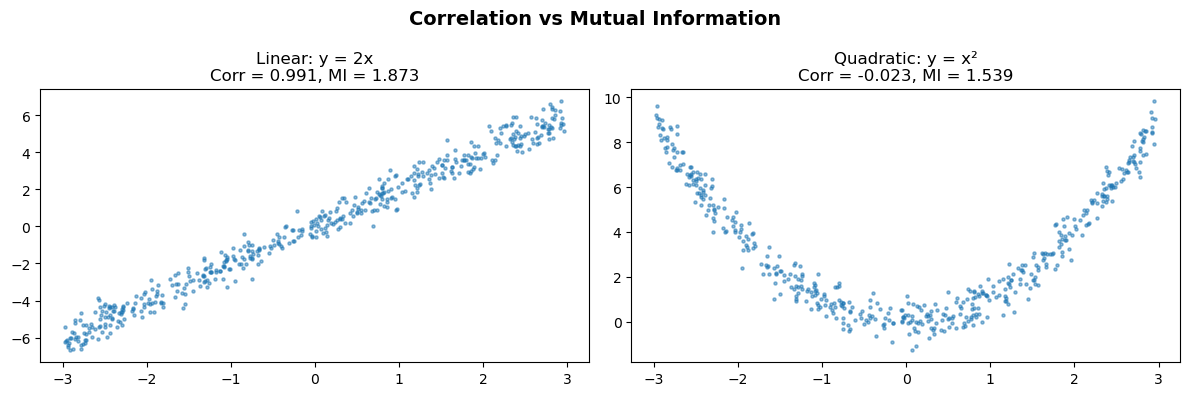

Linear:    Correlation = 0.991,  MI = 1.873
Quadratic: Correlation = -0.023,  MI = 1.539

Correlation MISSES the quadratic relationship (near 0)!
MI correctly identifies it as highly informative (1.539).
This is why we use MI for feature selection in Assignment 2.


In [11]:
# ---- Entropy & Mutual Information from Scratch ----

def entropy(labels):
    """Compute entropy of a discrete distribution."""
    _, counts = np.unique(labels, return_counts=True)
    probs = counts / len(labels)
    # Note: 0 * log(0) = 0 by convention
    return -np.sum(probs * np.log2(probs + 1e-10))

# ---- Example 1: Entropy of different distributions ----
print("Entropy Examples:")
print(f"  Fair coin [0.5, 0.5]:     {entropy([0,0,0,0,0,1,1,1,1,1]):.4f} bits")
print(f"  Loaded coin [0.9, 0.1]:   {entropy([0]*9 + [1]*1):.4f} bits")
print(f"  Two-headed [1.0, 0.0]:    {entropy([0]*10):.4f} bits")

# ---- Example 2: Mutual Information by hand ----
print("\n" + "=" * 60)
print("Mutual Information Example:")
print("=" * 60)

# Toy data: does knowing 'Weather' help predict 'Play Tennis'?
weather  = ['Sunny', 'Sunny', 'Rainy', 'Rainy', 'Cloudy', 'Cloudy', 'Sunny', 'Rainy', 'Cloudy', 'Cloudy']
play     = ['No',    'No',    'No',    'No',    'Yes',    'Yes',    'No',    'Yes',   'Yes',    'Yes']

# H(Play) - overall entropy
H_play = entropy(play)
print(f"\nH(Play Tennis) = {H_play:.4f} bits")
print(f"  (6 Yes, 4 No → moderate uncertainty)")

# H(Play | Weather) - entropy after knowing weather
# Split by weather, compute weighted average entropy
H_play_given_weather = 0
for w in ['Sunny', 'Rainy', 'Cloudy']:
    mask = [i for i, x in enumerate(weather) if x == w]
    play_subset = [play[i] for i in mask]
    weight = len(mask) / len(play)
    h = entropy(play_subset)
    print(f"  H(Play | Weather={w}): {h:.4f}  (weight={weight:.1f}, subset={play_subset})")
    H_play_given_weather += weight * h

print(f"\nH(Play | Weather) = {H_play_given_weather:.4f} bits")
print(f"MI(Weather, Play) = H(Play) - H(Play|Weather) = {H_play - H_play_given_weather:.4f} bits")
print(f"\nKnowing the weather reduces our uncertainty about playing tennis by {H_play - H_play_given_weather:.4f} bits.")

# ---- Example 3: MI catches nonlinear relationships that correlation misses ----
print("\n" + "=" * 60)
print("MI vs Correlation: Nonlinear Relationships")
print("=" * 60)

np.random.seed(42)
x = np.random.uniform(-3, 3, 500)
y_linear = 2 * x + np.random.normal(0, 0.5, 500)    # linear
y_quadratic = x**2 + np.random.normal(0, 0.5, 500)   # quadratic (U-shaped)

from sklearn.feature_selection import mutual_info_regression

mi_linear = mutual_info_regression(x.reshape(-1, 1), y_linear, random_state=42)[0]
mi_quadratic = mutual_info_regression(x.reshape(-1, 1), y_quadratic, random_state=42)[0]
corr_linear = np.corrcoef(x, y_linear)[0, 1]
corr_quadratic = np.corrcoef(x, y_quadratic)[0, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.scatter(x, y_linear, s=5, alpha=0.5)
ax1.set_title(f'Linear: y = 2x\nCorr = {corr_linear:.3f}, MI = {mi_linear:.3f}')
ax2.scatter(x, y_quadratic, s=5, alpha=0.5)
ax2.set_title(f'Quadratic: y = x²\nCorr = {corr_quadratic:.3f}, MI = {mi_quadratic:.3f}')
plt.suptitle('Correlation vs Mutual Information', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Linear:    Correlation = {corr_linear:.3f},  MI = {mi_linear:.3f}")
print(f"Quadratic: Correlation = {corr_quadratic:.3f},  MI = {mi_quadratic:.3f}")
print(f"\nCorrelation MISSES the quadratic relationship (near 0)!")
print(f"MI correctly identifies it as highly informative ({mi_quadratic:.3f}).")
print(f"This is why we use MI for feature selection in Assignment 2.")

## 4.3 XGBoost Feature Importance

XGBoost provides built-in feature importance through three metrics:

| Type | How it's computed | Meaning |
|------|------------------|---------|
| **Weight** | Number of times a feature appears in tree splits | Popular features (but can be misleading) |
| **Gain** | Average improvement in objective when a feature is used for splitting | Most reliable: measures actual predictive power |
| **Cover** | Average number of samples affected by splits on this feature | How broadly the feature influences predictions |

**Gain** is the most commonly used and is what XGBoost's `feature_importances_` returns by default.

### Limitation: High-Cardinality Bias

Features with many unique values (e.g., a continuous feature with 1000 distinct values) have more
possible split points, so they tend to appear more often in trees. This inflates their "weight"
importance even if they're not actually more predictive. **Gain** is less susceptible to this bias
because it measures actual improvement, not just frequency of use.

---
# Part 5: SHAP — Shapley Values from Game Theory

## 5.1 The Problem: Who Gets Credit?

Three friends (Alice, Bob, Charlie) start a lemonade stand together and earn $120. How should
they split the money fairly?

- Alice alone would earn $60
- Bob alone would earn $40
- Charlie alone would earn $20
- Alice + Bob together would earn $90
- Alice + Charlie together would earn $80
- Bob + Charlie together would earn $50
- All three together: $120

It's NOT as simple as splitting equally ($40 each) because Alice contributes more than Charlie.
And it's NOT just proportional to solo earnings because there are **interaction effects** (Alice + Bob
together earn $90, which is less than $60 + $40 = $100 — they overlap somewhat).

## 5.2 Shapley Values: The Fair Solution

Lloyd Shapley (Nobel Prize, 2012) proposed: compute each player's **marginal contribution** across
all possible orderings, then average.

### The Formula

$$\phi_i = \frac{1}{n!} \sum_{S \subseteq N \setminus \{i\}} \frac{|S|!(n-|S|-1)!}{n!}  [v(S \cup \{i\}) - v(S)]$$

In plain English: For every possible subset of other players, compute how much adding player $i$
improves the outcome. Average across all subsets, weighted by how many orderings produce that subset.

### Applied to ML: SHAP

Replace "players" with "features" and "earnings" with "prediction":

- Each **feature** is a player
- The **prediction** for a specific sample is the earnings
- $v(S)$: the model's prediction using only the features in set $S$ (others set to average/baseline)
- $\phi_i$: feature $i$'s SHAP value = its fair contribution to this prediction

In [12]:
# ---- Shapley Values from Scratch ----
from itertools import permutations, combinations

def shapley_values_exact(v_func, n_players):
    """
    Compute exact Shapley values for n players.
    v_func: function that takes a set of players (as frozenset) and returns the value.
    """
    players = list(range(n_players))
    shapley = np.zeros(n_players)

    # Method: enumerate all permutations
    all_perms = list(permutations(players))

    for perm in all_perms:
        for i, player in enumerate(perm):
            # Players who arrived before this player
            coalition_before = frozenset(perm[:i])
            coalition_with = frozenset(perm[:i+1])

            # Marginal contribution
            marginal = v_func(coalition_with) - v_func(coalition_before)
            shapley[player] += marginal

    shapley /= len(all_perms)
    return shapley

# ---- Lemonade Stand Example ----
def lemonade_value(coalition):
    """Value function for the lemonade stand."""
    coalition = set(coalition)
    if len(coalition) == 0: return 0
    values = {
        frozenset({0}): 60,           # Alice alone
        frozenset({1}): 40,           # Bob alone
        frozenset({2}): 20,           # Charlie alone
        frozenset({0, 1}): 90,        # Alice + Bob
        frozenset({0, 2}): 80,        # Alice + Charlie
        frozenset({1, 2}): 50,        # Bob + Charlie
        frozenset({0, 1, 2}): 120,    # All three
    }
    return values.get(frozenset(coalition), 0)

shapley = shapley_values_exact(lemonade_value, 3)
names = ['Alice', 'Bob', 'Charlie']

print("Lemonade Stand: Fair Profit Split (Shapley Values)")
print("=" * 50)
for name, sv in zip(names, shapley):
    print(f"  {name:>8}: ${sv:.2f}")
print(f"  {'Total':>8}: ${shapley.sum():.2f}")
print(f"\nThe split is fair: Alice gets the most (she contributes the most),")
print(f"Charlie gets the least, and it all adds up to $120.")

# ---- Show ALL 6 permutations explicitly ----
print("\n" + "=" * 50)
print("How it's computed (all 3! = 6 orderings):")
print("=" * 50)
all_perms = list(permutations(range(3)))
marginals = {name: [] for name in names}

for perm in all_perms:
    order_names = [names[p] for p in perm]
    print(f"\nOrder: {' → '.join(order_names)}")
    for i, player in enumerate(perm):
        before = frozenset(perm[:i])
        with_player = frozenset(perm[:i+1])
        v_before = lemonade_value(before)
        v_with = lemonade_value(with_player)
        marginal = v_with - v_before
        marginals[names[player]].append(marginal)
        print(f"  {names[player]} joins: ${v_before} → ${v_with}  (marginal = ${marginal})")

print("\nAverage marginal contributions:")
for name in names:
    vals = marginals[name]
    print(f"  {name}: {vals} → average = ${np.mean(vals):.2f}")

Lemonade Stand: Fair Profit Split (Shapley Values)
     Alice: $61.67
       Bob: $36.67
   Charlie: $21.67
     Total: $120.00

The split is fair: Alice gets the most (she contributes the most),
Charlie gets the least, and it all adds up to $120.

How it's computed (all 3! = 6 orderings):

Order: Alice → Bob → Charlie
  Alice joins: $0 → $60  (marginal = $60)
  Bob joins: $60 → $90  (marginal = $30)
  Charlie joins: $90 → $120  (marginal = $30)

Order: Alice → Charlie → Bob
  Alice joins: $0 → $60  (marginal = $60)
  Charlie joins: $60 → $80  (marginal = $20)
  Bob joins: $80 → $120  (marginal = $40)

Order: Bob → Alice → Charlie
  Bob joins: $0 → $40  (marginal = $40)
  Alice joins: $40 → $90  (marginal = $50)
  Charlie joins: $90 → $120  (marginal = $30)

Order: Bob → Charlie → Alice
  Bob joins: $0 → $40  (marginal = $40)
  Charlie joins: $40 → $50  (marginal = $10)
  Alice joins: $50 → $120  (marginal = $70)

Order: Charlie → Alice → Bob
  Charlie joins: $0 → $20  (marginal = $20)

## 5.3 SHAP for ML: TreeSHAP

Computing exact Shapley values requires evaluating $2^n$ subsets. With 52 features, that's
$2^{52} \approx 4.5 \times 10^{15}$ subsets — impossible.

**TreeSHAP** (Lundberg et al., 2020) exploits the tree structure of XGBoost to compute
exact Shapley values in **polynomial time** (not exponential). The key insight: for a decision tree,
removing a feature is equivalent to averaging over all branches that feature could have taken.
The tree structure lets us do this efficiently by tracing paths through the tree.

This is why we used `shap.TreeExplainer(xgb_model)` in Assignment 2 — it's fast and exact.

---
# Part 6: NLP — From Text to Predictions

## 6.1 The Fundamental Problem: Computers Can't Read

A model needs numbers, but text is... text. We need to convert words into numerical
representations that capture their meaning.

### Step 1: Tokenization

Split text into smaller pieces (**tokens**). There are several strategies:

| Method | "unhappiness" becomes | # Tokens |
|--------|----------------------|----------|
| **Word-level** | ["unhappiness"] | 1 |
| **Character-level** | ["u","n","h","a","p","p","i","n","e","s","s"] | 11 |
| **Subword (BPE)** | ["un", "happi", "ness"] | 3 |

Modern models use **Byte-Pair Encoding (BPE)** or similar subword methods because they balance
vocabulary size with the ability to handle rare/unknown words.

### Step 2: Embeddings

Each token is mapped to a **dense vector** (e.g., 768 dimensions). These vectors are learned
during training so that tokens with similar meanings end up close together in the vector space.

```
"king"  → [0.2, 0.8, -0.1, 0.5, ...]  (768 numbers)
"queen" → [0.3, 0.7, -0.2, 0.6, ...]  (similar to "king"!)
"apple" → [-0.5, 0.1, 0.9, -0.3, ...]  (far from "king")
```

The famous relationship: **king - man + woman ≈ queen** actually holds approximately in these
vector spaces. The model learns semantic relationships purely from reading text.

In [13]:
# ---- Tokenization in Practice ----
from transformers import AutoTokenizer

# Load the tokenizer used by our sentiment model
tokenizer = AutoTokenizer.from_pretrained("mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis")

# Example sentences
sentences = [
    "Apple reports record quarterly revenue",
    "Apple faces antitrust lawsuit from DOJ",
    "Stock market crashes amid recession fears",
]

print("Tokenization Examples:")
print("=" * 70)
for sent in sentences:
    tokens = tokenizer.tokenize(sent)
    token_ids = tokenizer.encode(sent, add_special_tokens=False)
    print(f"\nText:      '{sent}'")
    print(f"Tokens:    {tokens}")
    print(f"Token IDs: {token_ids}")
    print(f"# Tokens:  {len(tokens)}")

print("\n" + "=" * 70)
print("Notice:")
print("- Common words stay whole: 'Apple', 'Stock'")
print("- Less common words get split: 'antitrust' → 'ant', 'itrust' (subwords)")
print("- The 'Ġ' prefix means 'this token starts a new word' (space before it)")
print("- Each token maps to a unique integer ID from a vocabulary of ~50,000 tokens")

Tokenization Examples:

Text:      'Apple reports record quarterly revenue'
Tokens:    ['Apple', 'Ġreports', 'Ġrecord', 'Ġquarterly', 'Ġrevenue']
Token IDs: [20770, 690, 638, 3472, 903]
# Tokens:  5

Text:      'Apple faces antitrust lawsuit from DOJ'
Tokens:    ['Apple', 'Ġfaces', 'Ġantitrust', 'Ġlawsuit', 'Ġfrom', 'ĠDOJ']
Token IDs: [20770, 2419, 18849, 2672, 31, 19984]
# Tokens:  6

Text:      'Stock market crashes amid recession fears'
Tokens:    ['Stock', 'Ġmarket', 'Ġcrashes', 'Ġamid', 'Ġrecession', 'Ġfears']
Token IDs: [16822, 210, 12328, 2876, 7306, 4606]
# Tokens:  6

Notice:
- Common words stay whole: 'Apple', 'Stock'
- Less common words get split: 'antitrust' → 'ant', 'itrust' (subwords)
- The 'Ġ' prefix means 'this token starts a new word' (space before it)
- Each token maps to a unique integer ID from a vocabulary of ~50,000 tokens


## 6.2 Attention: The Key Innovation

### The Problem with Sequential Processing

RNNs/LSTMs process text **one word at a time**, left to right. For long sentences, early
words may be "forgotten" by the time we reach the end (even with LSTM gates).

### The Attention Mechanism

**Attention** lets the model look at **all words simultaneously** and decide which ones are
most relevant to each other.

For the sentence "The **bank** was on the **river** bank":
- When processing the first "bank", the model should **attend to** "river" to understand
  it means a riverbank, not a financial institution.

### Self-Attention: Query, Key, Value

Every token generates three vectors:
- **Query (Q)**: "What am I looking for?"
- **Key (K)**: "What do I contain?"
- **Value (V)**: "What information can I provide?"

For each token, we compute how much it should "attend to" every other token:

$$Attention(Q, K, V) = softmax\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

1. $QK^T$: Dot product of query with all keys → similarity scores
2. $/ \sqrt{d_k}$: Scale down to prevent scores from being too large
3. $softmax$: Convert to probabilities (sum to 1)
4. $\times V$: Weighted average of value vectors

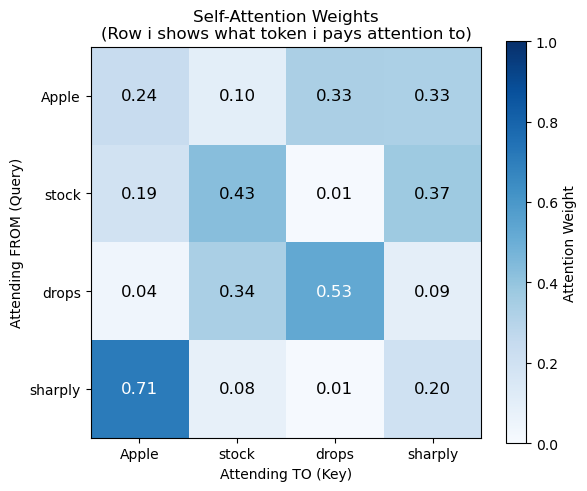

How to read this chart:
- Each ROW shows how much that word pays attention to every other word
- Higher values (darker blue) = stronger attention
- 'drops' might attend strongly to 'sharply' (they're related)
- In a trained model, these patterns capture real semantic relationships


In [14]:
# ---- Self-Attention from Scratch ----

def self_attention(X, Wq, Wk, Wv):
    """
    Compute self-attention.
    X: input embeddings (seq_len, d_model)
    Wq, Wk, Wv: weight matrices (d_model, d_k)
    """
    Q = X @ Wq     # Queries
    K = X @ Wk     # Keys
    V = X @ Wv     # Values

    d_k = K.shape[1]

    # Step 1: Compute attention scores (how much each token attends to others)
    scores = Q @ K.T / np.sqrt(d_k)

    # Step 2: Softmax to get attention weights (probabilities)
    exp_scores = np.exp(scores - scores.max(axis=-1, keepdims=True))  # numerical stability
    attention_weights = exp_scores / exp_scores.sum(axis=-1, keepdims=True)

    # Step 3: Weighted sum of values
    output = attention_weights @ V

    return output, attention_weights

# ---- Demo with a tiny sentence ----
np.random.seed(42)

# Simulated token embeddings for: "Apple stock drops sharply"
words = ["Apple", "stock", "drops", "sharply"]
seq_len = len(words)
d_model = 8   # embedding dimension (tiny for visualization; real models use 768)
d_k = 4       # query/key dimension

# Random embeddings (in reality, these come from the embedding layer)
X = np.random.randn(seq_len, d_model)

# Random weight matrices (in reality, these are learned)
Wq = np.random.randn(d_model, d_k) * 0.5
Wk = np.random.randn(d_model, d_k) * 0.5
Wv = np.random.randn(d_model, d_k) * 0.5

output, attn_weights = self_attention(X, Wq, Wk, Wv)

# Visualize attention weights
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(attn_weights, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(words)))
ax.set_yticks(range(len(words)))
ax.set_xticklabels(words)
ax.set_yticklabels(words)
ax.set_xlabel('Attending TO (Key)')
ax.set_ylabel('Attending FROM (Query)')
ax.set_title('Self-Attention Weights\n(Row i shows what token i pays attention to)')

# Add values
for i in range(len(words)):
    for j in range(len(words)):
        ax.text(j, i, f'{attn_weights[i, j]:.2f}', ha='center', va='center',
                fontsize=12, color='white' if attn_weights[i, j] > 0.5 else 'black')

plt.colorbar(im, ax=ax, label='Attention Weight')
plt.tight_layout()
plt.show()

print("How to read this chart:")
print("- Each ROW shows how much that word pays attention to every other word")
print("- Higher values (darker blue) = stronger attention")
print("- 'drops' might attend strongly to 'sharply' (they're related)")
print("- In a trained model, these patterns capture real semantic relationships")

## 6.3 Transformers: Stacking Attention

The **Transformer** architecture (Vaswani et al., 2017, "Attention Is All You Need") stacks
multiple self-attention layers:

```
Input Text → [Tokenize] → [Embed] → [Self-Attention Layer 1]
                                           ↓
                                     [Self-Attention Layer 2]
                                           ↓
                                         ...
                                     [Self-Attention Layer 12]
                                           ↓
                                     [Output / Classification]
```

Each layer refines the representation. Early layers capture **syntax** (word order, grammar).
Later layers capture **semantics** (meaning, relationships, sentiment).

**Multi-Head Attention**: Instead of one set of Q, K, V, the model uses **multiple heads** (e.g., 12).
Each head learns to attend to different types of relationships:
- Head 1 might learn syntax ("adjective → noun it modifies")
- Head 2 might learn sentiment ("negative words → subject they describe")
- Head 3 might learn coreference ("he → the person mentioned earlier")

## 6.4 BERT → RoBERTa → Financial Sentiment

### BERT (2018)

**BERT** (Bidirectional Encoder Representations from Transformers) was pre-trained on a massive
text corpus with two tasks:
1. **Masked Language Model**: Randomly hide 15% of words, predict them from context.
   "The [MASK] sat on the mat" → predict "cat"
2. **Next Sentence Prediction**: Given two sentences, predict if B follows A.

This pre-training teaches the model language understanding without any labeled data.

### RoBERTa (2019)

**RoBERTa** (Robustly optimized BERT) improves on BERT with:
- More training data (160GB vs 16GB)
- Longer training (more steps)
- Dynamic masking (different masks each epoch vs static)
- Removed Next Sentence Prediction (didn't help)

### Fine-Tuning for Financial Sentiment

The model we used (`distilroberta-finetuned-financial-news-sentiment-analysis`) takes a
pre-trained DistilRoBERTa (smaller, faster version) and adds a classification head:

```
"Apple reports record revenue" → [RoBERTa Encoder] → [768-dim vector] → [Linear + Softmax]
                                                                              ↓
                                                                   positive: 0.95
                                                                   neutral:  0.04
                                                                   negative: 0.01
```

The **fine-tuning** process trains this last classification layer (and slightly adjusts the
encoder weights) on a labeled dataset of financial news with known sentiments. The pre-trained
language understanding transfers, so you only need a few thousand labeled examples.

In [15]:
# ---- Full Sentiment Pipeline Demo ----
from transformers import pipeline, AutoModelForSequenceClassification

# Load the financial sentiment model
print("Loading financial sentiment model...")
sentiment = pipeline(
    "sentiment-analysis",
    model="mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis",
    top_k=None
)
print("Model loaded!\n")

# Test on various financial headlines
headlines = [
    "Apple reports record quarterly revenue beating analyst expectations",
    "Apple faces massive antitrust lawsuit threatening its app store",
    "Apple stock moves sideways in quiet trading session",
    "Federal Reserve raises interest rates by 50 basis points",
    "Tesla recalls 2 million vehicles over autopilot safety concerns",
    "Amazon reports 25% revenue growth driven by cloud services",
]

print(f"{'Headline':<70} {'Pos':>6} {'Neu':>6} {'Neg':>6}  {'Verdict':>10}")
print("=" * 110)

for headline in headlines:
    result = sentiment(headline)[0]
    scores = {r['label']: r['score'] for r in result}
    pos = scores.get('positive', 0)
    neg = scores.get('negative', 0)
    neu = scores.get('neutral', 0)

    # Determine verdict
    if pos > neg and pos > neu:
        verdict = "POSITIVE"
    elif neg > pos and neg > neu:
        verdict = "NEGATIVE"
    else:
        verdict = "NEUTRAL"

    # Truncate headline for display
    h_display = headline[:68] + ".." if len(headline) > 70 else headline
    print(f"{h_display:<70} {pos:>6.3f} {neu:>6.3f} {neg:>6.3f}  {verdict:>10}")

print("\n" + "=" * 110)
print("The model has learned to understand financial language:")
print("- 'record revenue' + 'beating expectations' → strongly positive")
print("- 'antitrust lawsuit' + 'threatening' → strongly negative")
print("- 'moves sideways' + 'quiet trading' → neutral")
print("- It even handles indirect effects: 'interest rate hike' → negative for stocks")

Loading financial sentiment model...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded!

Headline                                                                  Pos    Neu    Neg     Verdict
Apple reports record quarterly revenue beating analyst expectations     1.000  0.000  0.000    POSITIVE
Apple faces massive antitrust lawsuit threatening its app store         0.001  0.016  0.983    NEGATIVE
Apple stock moves sideways in quiet trading session                     0.001  0.003  0.996    NEGATIVE
Federal Reserve raises interest rates by 50 basis points                0.041  0.957  0.002     NEUTRAL
Tesla recalls 2 million vehicles over autopilot safety concerns         0.001  0.238  0.761    NEGATIVE
Amazon reports 25% revenue growth driven by cloud services              1.000  0.000  0.000    POSITIVE

The model has learned to understand financial language:
- 'record revenue' + 'beating expectations' → strongly positive
- 'antitrust lawsuit' + 'threatening' → strongly negative
- 'moves sideways' + 'quiet trading' → neutral
- It even handles indirect effe

---
# Summary: How Everything Connects in Assignment 2

| Step in Assignment 2 | What We Learned Here |
|----------------------|---------------------|
| Alpha158 features | These are computed from OHLCV using the rolling window techniques we saw |
| Feature Selection (MI) | MI measures how much each feature reduces uncertainty about tomorrow's return (Part 4) |
| XGBoost | Gradient boosted trees: each tree corrects previous errors, with regularization to prevent overfitting (Part 1) |
| MLP | Multiple layers of neurons with backpropagation learning, activated by nonlinear functions (Part 2) |
| LSTM | Sequence processor with gates that control memory, solving the vanishing gradient problem (Part 3) |
| SHAP | Shapley values from game theory: fairly attribute each feature's contribution to each prediction (Part 5) |
| Sentiment (RoBERTa) | Transformer-based model pre-trained on text, fine-tuned to classify financial news as positive/negative/neutral (Part 6) |

Each concept builds on simpler foundations. Understanding these foundations lets you:
1. **Debug** when things go wrong (e.g., why is my LSTM not converging? Check the loss curve.)
2. **Tune** hyperparameters intelligently (e.g., learning rate too high → overshooting)
3. **Choose** the right model for the problem (tabular data → XGBoost; sequences → LSTM)
4. **Explain** your results to others (SHAP values, feature importance)